In [22]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [35]:
def load_results(results_dir):
    """Load all JSON result files from the directory"""
    result_files = glob.glob(os.path.join(results_dir, "summary_all_dofs_*.json"))
    results = {}
    
    for file_path in result_files:
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                
            # Extract model type from filename
            filename = os.path.basename(file_path)
            model_type = filename.split('_')[3]  # Adjust based on your naming convention
            timestamp = filename.split('_')[4] + '_' + filename.split('_')[5].replace('.json', '')
            
            results[f"{model_type}_{timestamp}"] = data
            print(f"Loaded: {model_type} ({timestamp})")
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return results


def create_comparison_dataframes(all_results):
    """Create DataFrames for easy comparison across models"""
    
    # DataFrames to store metrics
    dof_metrics_list = []
    overall_metrics_list = []
    timing_metrics_list = []
    
    for model_key, result_data in all_results.items():
        model_type = model_key.split('_')[0]
        timestamp = '_'.join(model_key.split('_')[1:])
        
        # Extract per-DOF metrics
        if 'all_test_scores' in result_data:
            for dof, metrics in result_data['all_test_scores'].items():
                if isinstance(metrics, dict):
                    # Normal case: metrics is a dictionary
                    row = {
                        'model': model_type,
                        'timestamp': timestamp,
                        'dof': dof,
                        'accuracy': metrics.get('accuracy', np.nan),
                        'precision': metrics.get('precision', np.nan),
                        'recall': metrics.get('recall', np.nan),
                        'f1': metrics.get('f1', np.nan),
                        'auc_roc': metrics.get('auc_roc', np.nan)
                    }
                    dof_metrics_list.append(row)
                elif isinstance(metrics, (int, float)):
                    # Case where metrics is just a single value (probably accuracy)
                    row = {
                        'model': model_type,
                        'timestamp': timestamp,
                        'dof': dof,
                        'accuracy': float(metrics),
                        'precision': np.nan,
                        'recall': np.nan,
                        'f1': np.nan,
                        'auc_roc': np.nan
                    }
                    dof_metrics_list.append(row)
                    print(f"  Note: {dof} has simple metric value: {metrics}")
                else:
                    print(f"  Warning: Unknown metrics type for {dof}: {type(metrics)}")
        
        # Extract overall system metrics
        if 'overall_system_scores' in result_data:
            overall_metrics = result_data['overall_system_scores']
            overall_row = {
                'model': model_type,
                'timestamp': timestamp,
                'overall_accuracy': overall_metrics.get('overall_accuracy', np.nan),
                'n_correct_samples': overall_metrics.get('n_correct_samples', np.nan),
                'n_total_samples': overall_metrics.get('n_total_samples', np.nan),
                'correct_percentage': overall_metrics.get('correct_percentage', np.nan)
            }
            overall_metrics_list.append(overall_row)
        
        # Extract timing information
        if 'overall_timing' in result_data:
            for dof, timing in result_data['overall_timing'].items():
                timing_row = {
                    'model': model_type,
                    'timestamp': timestamp,
                    'dof': dof,
                    'training_time': timing.get('training_time', np.nan),
                    'test_time': timing.get('test_time', np.nan),
                    'avg_inference_time': timing.get('avg_inference_time', np.nan),
                    'total_time': timing.get('training_time', 0) + timing.get('test_time', 0)
                }
                timing_metrics_list.append(timing_row)
    
    # Create DataFrames
    dof_df = pd.DataFrame(dof_metrics_list)
    overall_df = pd.DataFrame(overall_metrics_list)
    timing_df = pd.DataFrame(timing_metrics_list)
    
    return dof_df, overall_df, timing_df

In [36]:
results_dir = r"C:\Users\miski\Desktop\Neuro-X\N-Pulse\BMI-SOFT-Signal_Processing_ML\results\timing"  # Update this path
all_results = load_results(results_dir)
print(f"\nLoaded {len(all_results)} result sets")

Loaded: DecisionTree (20251130_165810)
Loaded: GaussianNB (20251130_165916)
Loaded: LDA (20251130_165713)
Loaded: LDA (20251130_174251)
Loaded: RandomForest (20251130_170808)
Loaded: SVM (20251130_170145)

Loaded 6 result sets


In [37]:
dof_df, overall_df, timing_df = create_comparison_dataframes(all_results)

print("Per-DOF Metrics DataFrame:")
print(dof_df.head())
print(f"\nShape: {dof_df.shape}")

print("\nOverall Metrics DataFrame:")
print(overall_df.head())

print("\nTiming Metrics DataFrame:")
print(timing_df.head())

  Note: wrist_flex_ext has simple metric value: 0.856694560669456
  Note: thumb_flex_ext has simple metric value: 0.8608786610878661
  Note: thumb_abd_add has simple metric value: 0.8556485355648535
  Note: index_flex_ext has simple metric value: 0.8294979079497908
  Note: middle_flex_ext has simple metric value: 0.8294979079497908
  Note: ring_flex_ext has simple metric value: 0.8294979079497908
  Note: pinky_flex_ext has simple metric value: 0.8294979079497908
  Note: wrist_flex_ext has simple metric value: 0.75418410041841
  Note: thumb_flex_ext has simple metric value: 0.3389121338912134
  Note: thumb_abd_add has simple metric value: 0.3389121338912134
  Note: index_flex_ext has simple metric value: 0.4006276150627615
  Note: middle_flex_ext has simple metric value: 0.4006276150627615
  Note: ring_flex_ext has simple metric value: 0.4006276150627615
  Note: pinky_flex_ext has simple metric value: 0.4006276150627615
  Note: wrist_flex_ext has simple metric value: 0.8399581589958159


In [38]:
def plot_model_comparison(dof_df, metric='accuracy'):
    """Compare models across all DOFs for a specific metric"""
    plt.figure(figsize=(12, 6))
    
    # Create pivot table for easy plotting
    pivot_data = dof_df.pivot_table(
        values=metric, 
        index='dof', 
        columns='model', 
        aggfunc='mean'
    )
    
    # Plot
    ax = pivot_data.plot(kind='bar', figsize=(14, 8))
    plt.title(f'Model Comparison - {metric.capitalize()} by DOF', fontsize=16, fontweight='bold')
    plt.xlabel('Degree of Freedom (DOF)', fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)
    plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return pivot_data

def plot_overall_performance(overall_df):
    """Plot overall system performance"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Overall accuracy
    overall_df.groupby('model')['overall_accuracy'].mean().sort_values().plot(
        kind='barh', ax=axes[0], color='skyblue'
    )
    axes[0].set_title('Overall System Accuracy by Model', fontweight='bold')
    axes[0].set_xlabel('Accuracy')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Correct samples
    overall_df.groupby('model')['correct_percentage'].mean().sort_values().plot(
        kind='barh', ax=axes[1], color='lightcoral'
    )
    axes[1].set_title('Correct Classification Percentage', fontweight='bold')
    axes[1].set_xlabel('Percentage (%)')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_timing_comparison(timing_df):
    """Compare training and inference times"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Average training time by model
    timing_df.groupby('model')['training_time'].mean().sort_values().plot(
        kind='bar', ax=axes[0,0], color='orange'
    )
    axes[0,0].set_title('Average Training Time by Model', fontweight='bold')
    axes[0,0].set_ylabel('Time (seconds)')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Average test time by model
    timing_df.groupby('model')['avg_inference_time'].mean().sort_values().plot(
        kind='bar', ax=axes[0,1], color='green'
    )
    axes[0,1].set_title('Average Inference Time by Model', fontweight='bold')
    axes[0,1].set_ylabel('Time (seconds)')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Total time by DOF and model
    timing_pivot = timing_df.pivot_table(
        values='total_time', 
        index='dof', 
        columns='model', 
        aggfunc='mean'
    )
    timing_pivot.plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Total Time by DOF and Model', fontweight='bold')
    axes[1,0].set_ylabel('Time (seconds)')
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Time distribution
    timing_df.boxplot(column='total_time', by='model', ax=axes[1,1])
    axes[1,1].set_title('Total Time Distribution by Model', fontweight='bold')
    axes[1,1].set_ylabel('Time (seconds)')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.suptitle('')  # Remove automatic subtitle
    plt.tight_layout()
    plt.show()

def plot_metric_correlation(dof_df):
    """Plot correlation between different metrics"""
    metrics_to_correlate = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
    correlation_data = dof_df[metrics_to_correlate].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
    plt.title('Correlation Between Different Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_performance_heatmap(dof_df):
    """Create a heatmap of performance across DOFs and models"""
    heatmap_data = dof_df.pivot_table(
        values='accuracy', 
        index='model', 
        columns='dof', 
        aggfunc='mean'
    )
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', 
                fmt='.3f', cbar_kws={'label': 'Accuracy'})
    plt.title('Accuracy Heatmap: Models vs DOFs', fontsize=16, fontweight='bold')
    plt.xlabel('Degree of Freedom')
    plt.ylabel('Model Type')
    plt.tight_layout()
    plt.show()

=== MODEL COMPARISON ACROSS DOFs ===


<Figure size 1200x600 with 0 Axes>

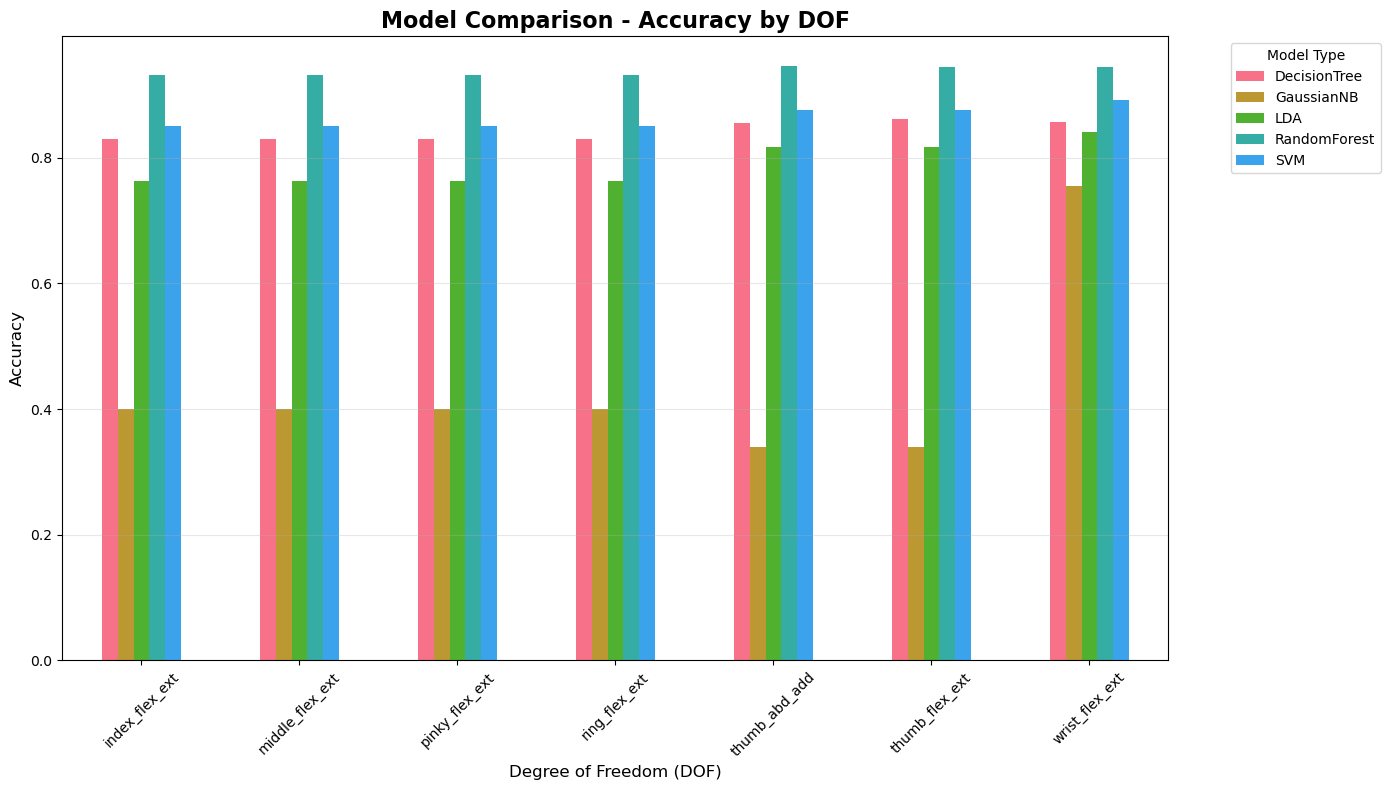


=== OVERALL SYSTEM PERFORMANCE ===


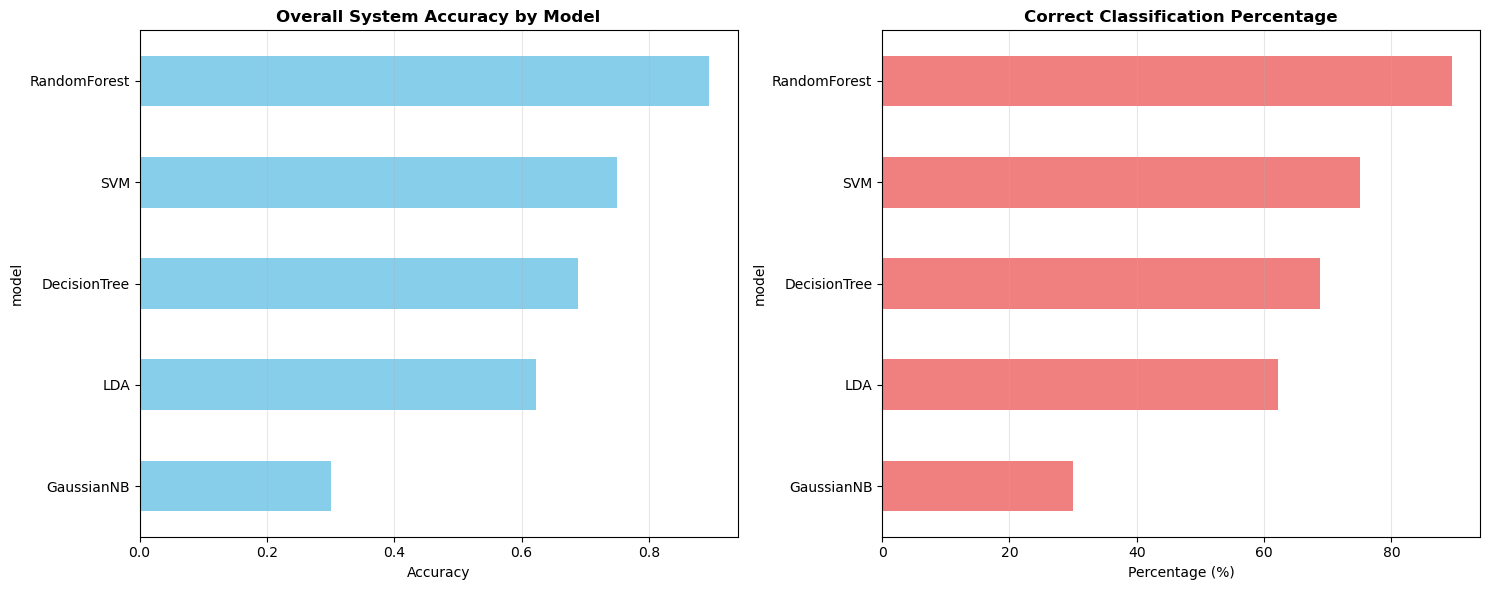


=== TIMING ANALYSIS ===


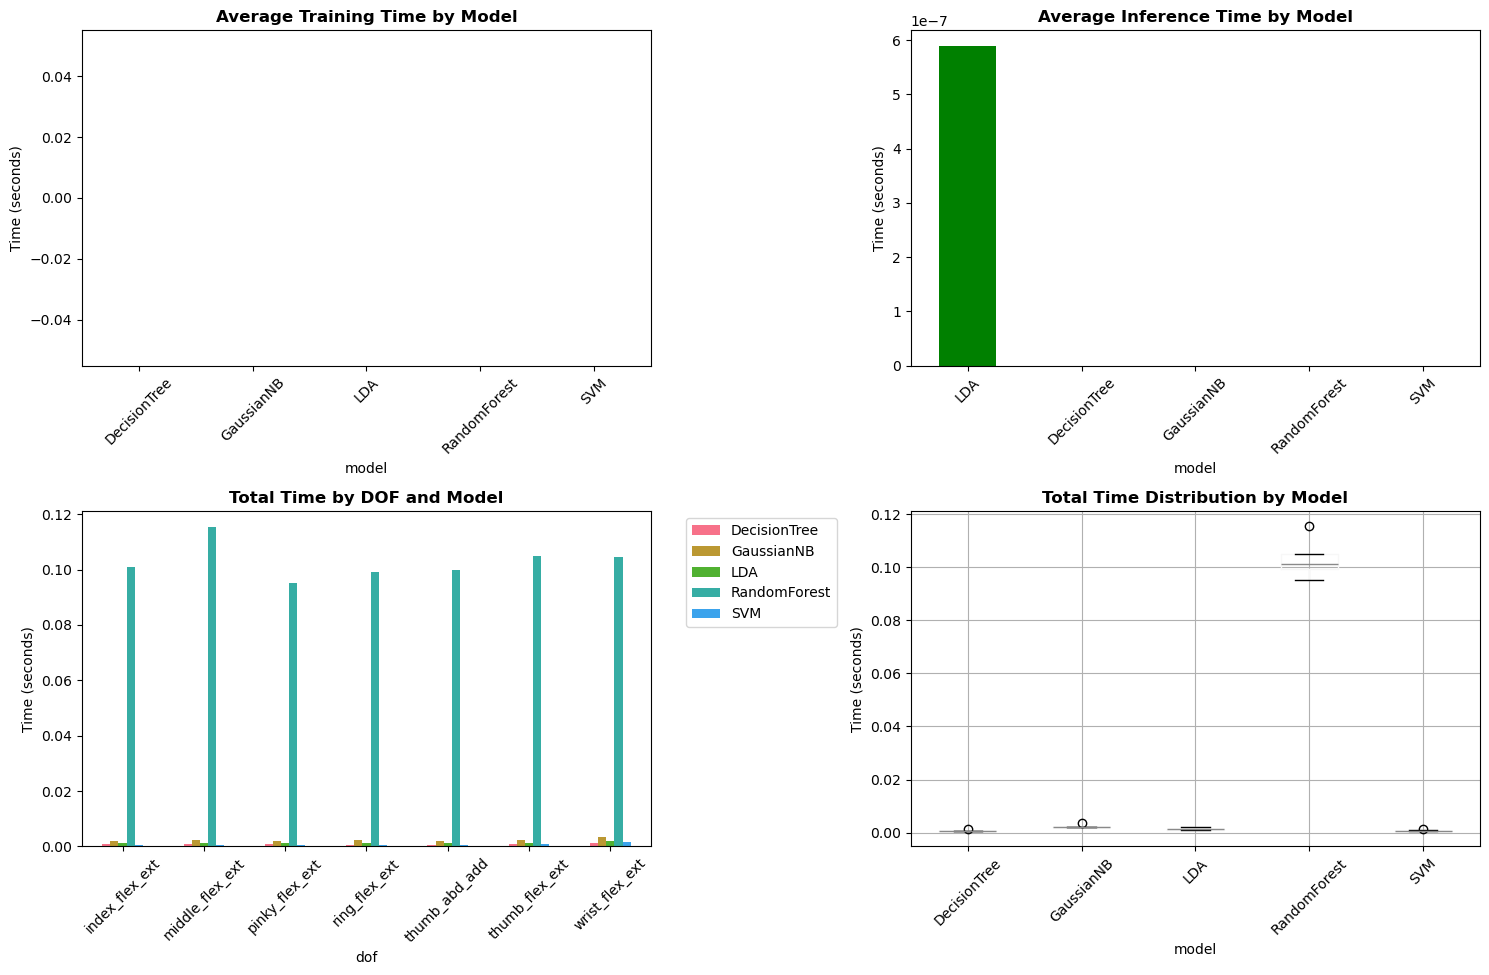


=== METRIC CORRELATIONS ===


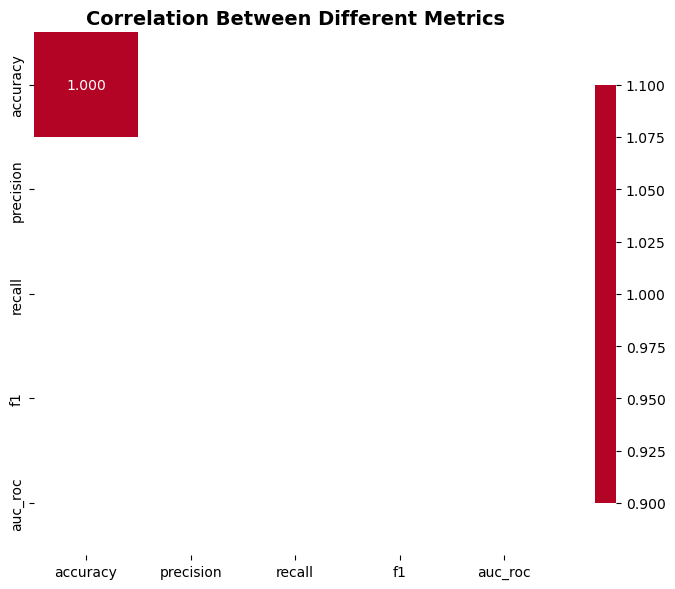


=== PERFORMANCE HEATMAP ===


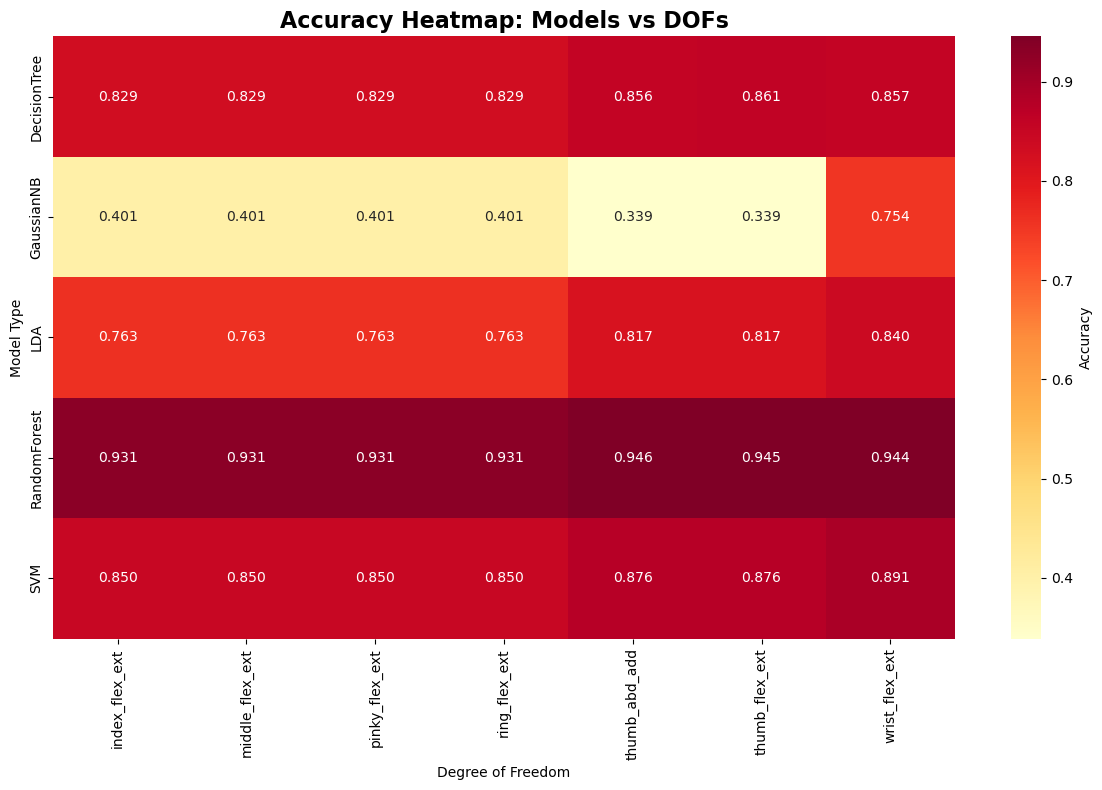

In [40]:
print("=== MODEL COMPARISON ACROSS DOFs ===")
for metric in ['accuracy']:
    pivot_data = plot_model_comparison(dof_df, metric)

print("\n=== OVERALL SYSTEM PERFORMANCE ===")
plot_overall_performance(overall_df)

print("\n=== TIMING ANALYSIS ===")
plot_timing_comparison(timing_df)

print("\n=== METRIC CORRELATIONS ===")
plot_metric_correlation(dof_df)

print("\n=== PERFORMANCE HEATMAP ===")
plot_performance_heatmap(dof_df)

In [28]:
def print_statistical_summary(dof_df, overall_df):
    """Print comprehensive statistical summary"""
    
    print("="*60)
    print("STATISTICAL SUMMARY")
    print("="*60)
    
    # Per-DOF statistics
    print("\n1. PER-DOF PERFORMANCE RANKINGS:")
    dof_summary = dof_df.groupby('model').agg({
        'accuracy': ['mean', 'std', 'min', 'max'],
        'f1': ['mean', 'std']
    }).round(4)
    print(dof_summary)
    
    # Overall rankings
    print("\n2. OVERALL SYSTEM PERFORMANCE RANKINGS:")
    overall_rankings = overall_df.groupby('model')['overall_accuracy'].agg([
        'mean', 'std', 'min', 'max'
    ]).round(4).sort_values('mean', ascending=False)
    print(overall_rankings)
    
    # Best model for each DOF
    print("\n3. BEST MODEL FOR EACH DOF:")
    best_models = dof_df.loc[dof_df.groupby('dof')['accuracy'].idxmax()]
    print(best_models[['dof', 'model', 'accuracy']].round(4))
    
    return dof_summary, overall_rankings

In [29]:

dof_summary, overall_rankings = print_statistical_summary(dof_df, overall_df)

STATISTICAL SUMMARY

1. PER-DOF PERFORMANCE RANKINGS:
             accuracy                           f1    
                 mean     std     min     max mean std
model                                                 
DecisionTree   0.8416  0.0152  0.8295  0.8609  NaN NaN
GaussianNB     0.4335  0.1444  0.3389  0.7542  NaN NaN
LDA            0.7892  0.0327  0.7626  0.8400  NaN NaN
RandomForest   0.9368  0.0073  0.9310  0.9456  NaN NaN
SVM            0.8634  0.0170  0.8504  0.8912  NaN NaN

2. OVERALL SYSTEM PERFORMANCE RANKINGS:
                mean  std     min     max
model                                    
RandomForest  0.8944  NaN  0.8944  0.8944
SVM           0.7500  NaN  0.7500  0.7500
DecisionTree  0.6883  NaN  0.6883  0.6883
LDA           0.6224  0.0  0.6224  0.6224
GaussianNB    0.3002  NaN  0.3002  0.3002

3. BEST MODEL FOR EACH DOF:
                dof         model  accuracy
31   index_flex_ext  RandomForest    0.9310
32  middle_flex_ext  RandomForest    0.9310
34   pinky

In [30]:
def plot_performance_vs_time(dof_df, timing_df):
    """Plot performance vs computational cost"""
    # Merge performance and timing data
    merged_df = pd.merge(
        dof_df.groupby('model').agg({'accuracy': 'mean'}).reset_index(),
        timing_df.groupby('model').agg({'total_time': 'mean'}).reset_index(),
        on='model'
    )
    
    plt.figure(figsize=(10, 6))
    plt.scatter(merged_df['total_time'], merged_df['accuracy'], s=100, alpha=0.7)
    
    # Add labels
    for i, row in merged_df.iterrows():
        plt.annotate(row['model'], 
                    (row['total_time'], row['accuracy']),
                    xytext=(5, 5), textcoords='offset points')
    
    plt.xlabel('Average Total Time (seconds)')
    plt.ylabel('Average Accuracy')
    plt.title('Performance vs Computational Cost', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_model_consistency(dof_df):
    """Plot consistency of models across different DOFs"""
    consistency = dof_df.groupby('model')['accuracy'].std().sort_values()
    
    plt.figure(figsize=(10, 6))
    consistency.plot(kind='bar', color='purple', alpha=0.7)
    plt.title('Model Consistency Across DOFs (Lower is Better)', fontweight='bold')
    plt.ylabel('Standard Deviation of Accuracy')
    plt.xlabel('Model Type')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


=== ADVANCED ANALYSIS ===


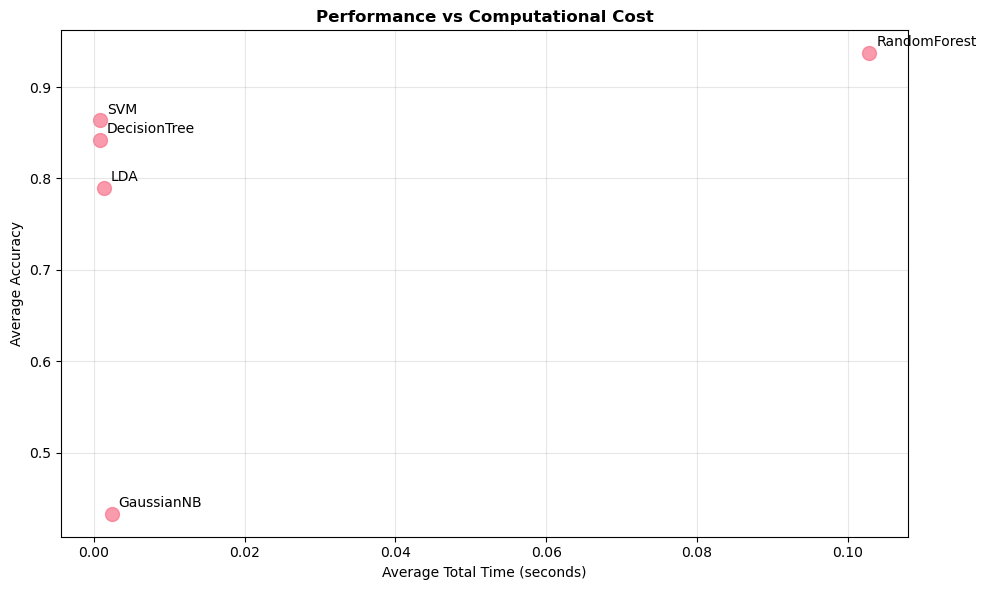

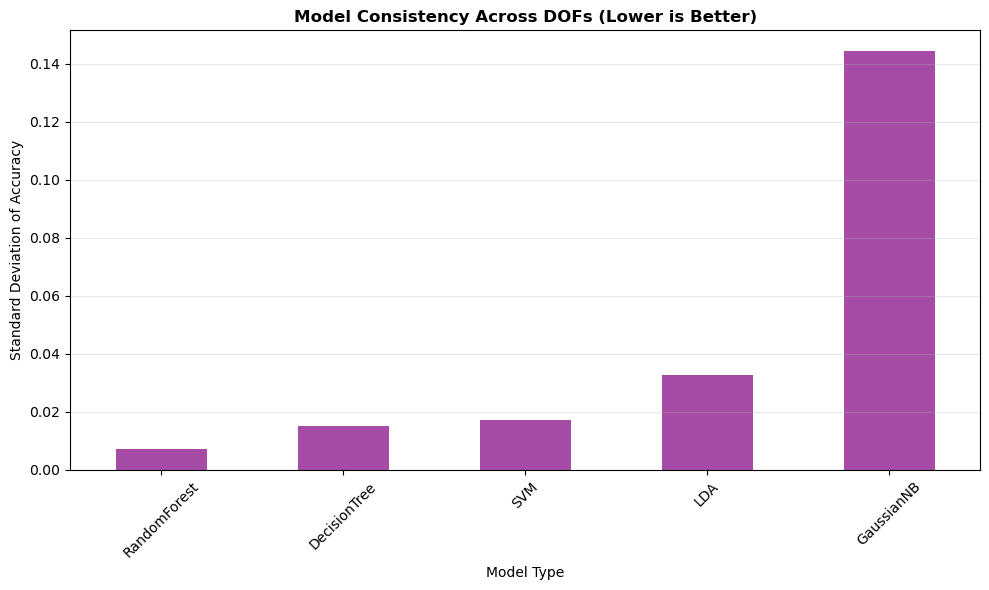

In [31]:
# Generate advanced plots
print("=== ADVANCED ANALYSIS ===")
plot_performance_vs_time(dof_df, timing_df)
plot_model_consistency(dof_df)